               close      high       low      open     volume  log_return
Date                                                                     
2010-01-05  7.656429  7.699643  7.616071  7.664286  601904800    0.001727
2010-01-06  7.534643  7.686786  7.526786  7.656429  552160000   -0.016034
2010-01-07  7.520714  7.571429  7.466071  7.562500  477131200   -0.001850
2010-01-08  7.570714  7.571429  7.466429  7.510714  447610800    0.006626
2010-01-11  7.503929  7.607143  7.444643  7.600000  462229600   -0.008861
             close         high          low         open        volume  \
count  4113.000000  4113.000000  4113.000000  4113.000000  4.113000e+03   
mean     83.894801    84.727029    82.987440    83.828684  2.151722e+08   
std      78.643866    79.414447    77.796814    78.565139  2.145883e+08   
min       6.858929     7.000000     6.794643     6.870357  1.791060e+07   
25%      21.775000    21.976786    21.575001    21.831429  7.548600e+07   
50%      42.700001    43.002499 

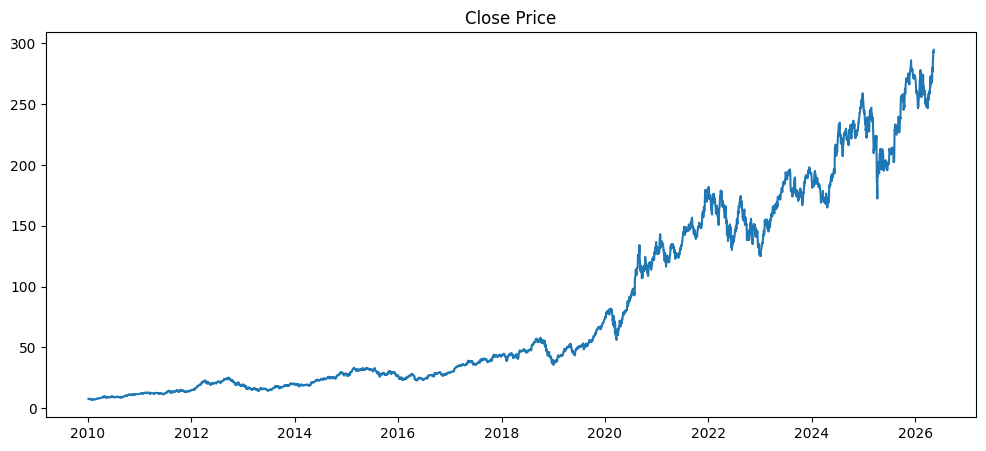

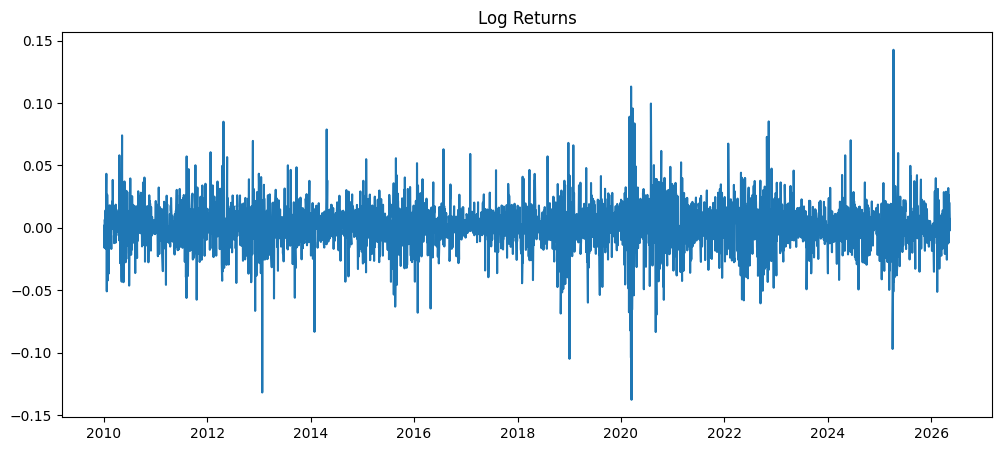

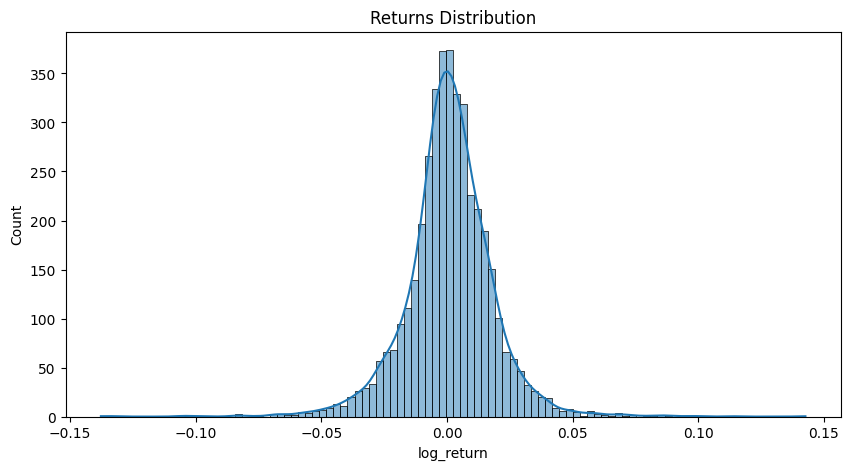

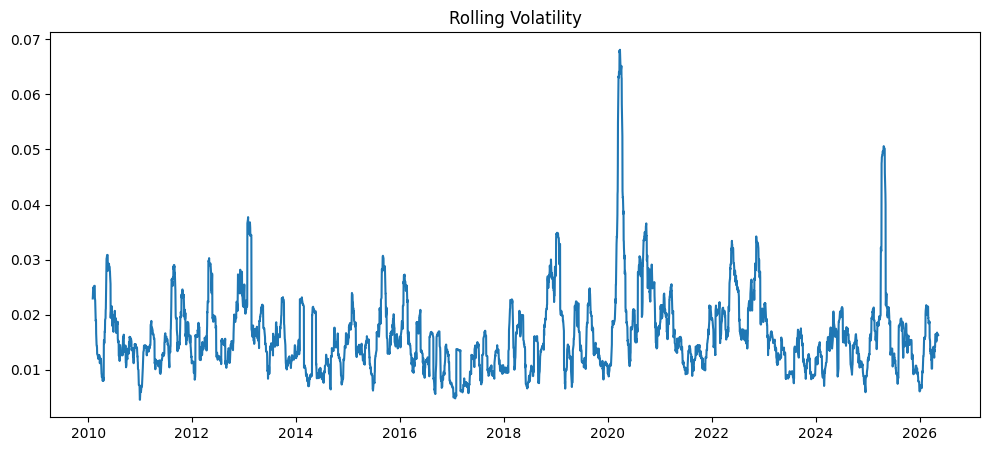

EDA DONE


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ticker = "AAPL"

raw = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False,
    threads=False
)

df = pd.DataFrame(index=raw.index)

for col in raw.columns:
    col_name = str(col).lower()

    if "close" in col_name:
        df["close"] = raw[col]

    if "open" in col_name:
        df["open"] = raw[col]

    if "high" in col_name:
        df["high"] = raw[col]

    if "low" in col_name:
        df["low"] = raw[col]

    if "volume" in col_name:
        df["volume"] = raw[col]


if "close" not in df.columns:
    raise ValueError(f"Close still missing. Raw columns: {raw.columns}")

df = df.dropna()


df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df = df.dropna()

print(df.head())
print(df.describe())


plt.figure(figsize=(12,5))
plt.plot(df["close"])
plt.title("Close Price")
plt.show()


plt.figure(figsize=(12,5))
plt.plot(df["log_return"])
plt.title("Log Returns")
plt.show()


plt.figure(figsize=(10,5))
sns.histplot(df["log_return"], bins=100, kde=True)
plt.title("Returns Distribution")
plt.show()


df["volatility"] = df["log_return"].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(df["volatility"])
plt.title("Rolling Volatility")
plt.show()

print("EDA DONE")